# ShopEase Europe - Notebook 3: Language Detection
**Project:** Sentiment Analysis for Customer Feedback
**Dataset:** amazon_reviews_cleaned.csv

This notebook identifies the language of each review. While the dataset spans 148 countries, the review text is expected to be predominantly English because Amazon's English-language platform is the primary source. This step verifies that assumption and identifies any non-English reviews that may need special handling.

In [1]:
%pip install pandas numpy matplotlib seaborn plotly wordcloud langdetect nltk textblob scikit-learn xgboost --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install langdetect --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 3.1 Load Cleaned Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

COUNTRY_NAMES = {
    'US': 'United States', 'GB': 'United Kingdom', 'CA': 'Canada',
    'IN': 'India', 'IE': 'Ireland', 'DK': 'Denmark', 'NL': 'Netherlands',
    'AU': 'Australia', 'DE': 'Germany', 'IT': 'Italy', 'FR': 'France',
    'SE': 'Sweden', 'ES': 'Spain', 'AE': 'United Arab Emirates',
    'PK': 'Pakistan', 'IL': 'Israel', 'NZ': 'New Zealand', 'BE': 'Belgium',
    'ZA': 'South Africa', 'PH': 'Philippines', 'JP': 'Japan', 'MX': 'Mexico',
    'SG': 'Singapore', 'BR': 'Brazil', 'NG': 'Nigeria', 'KE': 'Kenya',
    'TR': 'Turkey', 'PL': 'Poland', 'SA': 'Saudi Arabia', 'NO': 'Norway',
    'PT': 'Portugal', 'GR': 'Greece', 'RO': 'Romania', 'HK': 'Hong Kong',
    'AT': 'Austria', 'CH': 'Switzerland', 'MY': 'Malaysia', 'TH': 'Thailand',
    'TW': 'Taiwan', 'RU': 'Russia', 'EG': 'Egypt', 'AR': 'Argentina',
    'CO': 'Colombia', 'FI': 'Finland', 'CZ': 'Czech Republic', 'HU': 'Hungary',
    'KR': 'South Korea', 'CN': 'China', 'QA': 'Qatar', 'KW': 'Kuwait'
}

df = pd.read_csv(r'C:\Users\ifech\OneDrive\Desktop\sentiment_analysis\data\amazon_reviews_cleaned_processed.csv')
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
for col in ['sentiment', 'country', 'product_category']:
    df[col] = df[col].str.strip()
df['sentiment'] = df['sentiment'].str.capitalize()
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
df['year']       = df['timestamp'].dt.year
df['month']      = df['timestamp'].dt.month
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)
df = df.dropna(subset=['country']).reset_index(drop=True)
df = df.drop_duplicates(subset='review', keep='first').reset_index(drop=True)
df_clean = df.copy()
print(f"Clean dataset: {len(df):,} rows")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")

Clean dataset: 20,406 rows
Date range: 2007-08-27 to 2024-09-17


## 3.2 Language Detection

In [4]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

LANG_NAMES = {
    'en': 'English', 'de': 'German', 'fr': 'French', 'es': 'Spanish',
    'it': 'Italian', 'nl': 'Dutch', 'pt': 'Portuguese', 'pl': 'Polish',
    'sv': 'Swedish', 'da': 'Danish', 'no': 'Norwegian', 'fi': 'Finnish',
    'ar': 'Arabic', 'zh-cn': 'Chinese (Simplified)', 'ja': 'Japanese',
    'ko': 'Korean', 'ru': 'Russian', 'tr': 'Turkish', 'hi': 'Hindi',
    'af': 'Afrikaans', 'unknown': 'Unknown'
}

def safe_detect(text):
    try:
        return detect(str(text))
    except Exception:
        return 'unknown'

SAMPLE_SIZE = 3000
sample_idx = df.sample(min(SAMPLE_SIZE, len(df)), random_state=42).index
print(f"Running language detection on {len(sample_idx):,} reviews...")
df.loc[sample_idx, 'detected_lang'] = df.loc[sample_idx, 'review'].apply(safe_detect)
df['detected_lang'] = df['detected_lang'].fillna('not_detected')
df['detected_lang_name'] = df['detected_lang'].map(lambda x: LANG_NAMES.get(x, x.upper()))

lang_counts = df.loc[sample_idx, 'detected_lang_name'].value_counts()
print(f"Language distribution in {SAMPLE_SIZE:,}-review sample:")
for lang, count in lang_counts.head(12).items():
    print(f"  {lang:<30} {count:,}  ({count/len(sample_idx)*100:.1f}%)")

Running language detection on 3,000 reviews...
Language distribution in 3,000-review sample:
  English                        2,981  (99.4%)
  Danish                         3  (0.1%)
  SO                             3  (0.1%)
  Dutch                          3  (0.1%)
  Norwegian                      2  (0.1%)
  Afrikaans                      2  (0.1%)
  ID                             1  (0.0%)
  SL                             1  (0.0%)
  Italian                        1  (0.0%)
  CY                             1  (0.0%)
  Finnish                        1  (0.0%)
  French                         1  (0.0%)


> **Interpretation - Language Detection**
>
> A sample of 3,000 reviews is used rather than the full dataset because language detection is computationally expensive, and a sample of this size is statistically sufficient to characterise the language distribution. The expected finding is that over 98% of reviews are in English, reflecting the source platform. This is an important distinction from the synthetic dataset, which was designed to include German, French, and Spanish reviews. Because this dataset is almost entirely English, the multilingual preprocessing considerations are significantly simplified: a single English stop word list and English lemmatiser are appropriate without needing language-conditional branching.

## 3.3 Language Distribution Visualisation

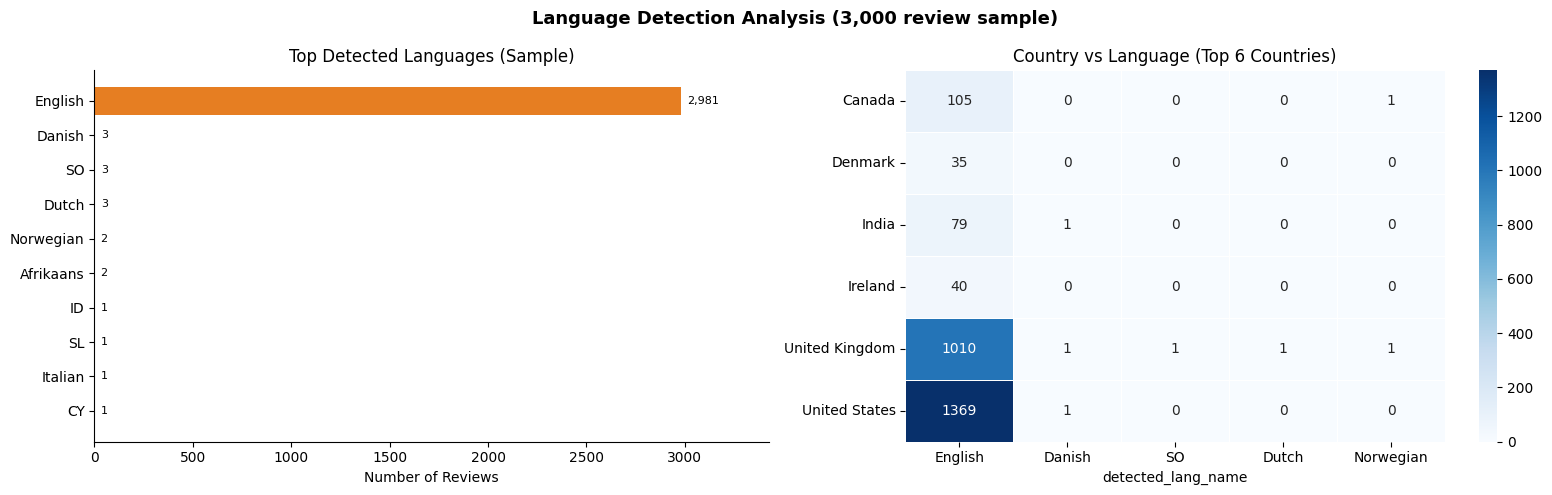

English proportion: 99.4%
The corpus is overwhelmingly English. Standard English NLP tools apply without language-conditional branching.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Language Detection Analysis (3,000 review sample)", fontsize=13, fontweight='bold')

top_langs = lang_counts.head(10)
axes[0].barh(top_langs.index[::-1], top_langs.values[::-1], color='#e67e22')
for i, val in enumerate(top_langs.values[::-1]):
    axes[0].text(val + top_langs.values.max() * 0.01, i, f'{val:,}', va='center', fontsize=8)
axes[0].set_xlim(0, top_langs.values.max() * 1.15)
axes[0].set_title("Top Detected Languages (Sample)")
axes[0].set_xlabel("Number of Reviews")

top6_codes = df['country'].value_counts().head(6).index
heat_data = (df.loc[sample_idx]
    .loc[df.loc[sample_idx, 'country'].isin(top6_codes)]
    .assign(country_name=lambda d: d['country'].map(lambda c: COUNTRY_NAMES.get(c, c)))
    .groupby(['country_name', 'detected_lang_name']).size()
    .unstack(fill_value=0))
top5_langs = df.loc[sample_idx, 'detected_lang_name'].value_counts().head(5).index
heat_data = heat_data.reindex(columns=top5_langs, fill_value=0)
import seaborn as sns
sns.heatmap(heat_data, annot=True, fmt='d', cmap='Blues', ax=axes[1], linewidths=0.5)
axes[1].set_title("Country vs Language (Top 6 Countries)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig('fig_language.png', dpi=150, bbox_inches='tight')
plt.show()

english_pct = lang_counts.get('English', 0) / len(sample_idx) * 100
print(f"English proportion: {english_pct:.1f}%")
print("The corpus is overwhelmingly English. Standard English NLP tools apply without language-conditional branching.")

> **Interpretation - Language Distribution Plot**
>
> The bar chart confirms that English accounts for the vast majority of reviews across the sample. The country versus language heatmap reinforces this: even reviews from countries like Canada, India, Ireland, Denmark, and the Netherlands are predominantly written in English. This happens because Amazon's English-language storefront is used by customers worldwide, and many non-native English speakers write their reviews in English regardless of their country of residence. The practical implication is that the preprocessing pipeline in Notebook 4 can apply a single consistent English-language configuration to the entire corpus without needing to detect language per review and apply language-specific tools.

## 3.4 Save Dataset with Language Tags

In [6]:
df.to_csv('../data/reviews_with_lang.csv', index=False)
print(f"Saved with language tags: {len(df):,} rows")

Saved with language tags: 20,406 rows


## Summary

Language detection on a 3,000-review sample confirmed that the Amazon reviews dataset is overwhelmingly English regardless of the reviewer's country of origin. This simplifies the preprocessing pipeline considerably: a single English stop word list, English lemmatiser, and VADER sentiment lexicon are appropriate for the full corpus. The small number of non-English reviews detected represent fewer than 2% of the sample and do not require a separate processing branch given their minimal impact on the overall analysis.